In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("../figures/model_performance_summary.csv")

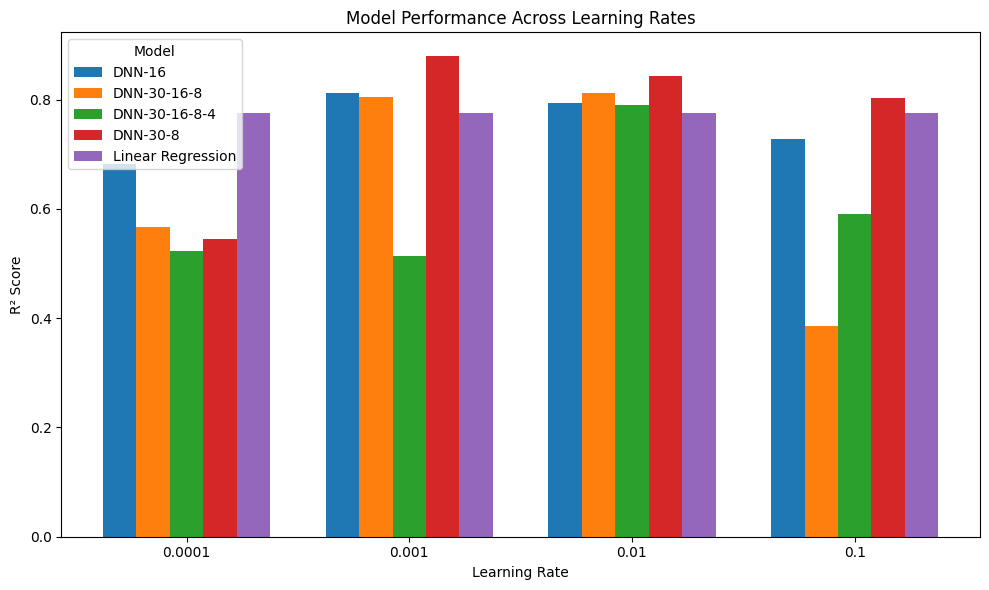

In [39]:
df = df.sort_values(["learning rate", "model"])
lrs = sorted(df["learning rate"].unique())
models = df["model"].unique()

# Width of a single bar and bar positions
bar_width = 0.15
x = np.arange(len(lrs))  # positions for learning rates

plt.figure(figsize=(10,6))

for i, model in enumerate(models):
    model_scores = []
    for lr in lrs:
        row = df[(df["model"] == model) & (df["learning rate"] == lr)]
        if not row.empty:
            model_scores.append(row["r2"].values[0])
        else:
            model_scores.append(np.nan)
    plt.bar(x + i*bar_width, model_scores, width=bar_width, label=model)

# Format plot
plt.xticks(x + (len(models)-1)*bar_width/2, lrs)  # center xticks
plt.xlabel("Learning Rate")
plt.ylabel("R² Score")
plt.title("Model Performance Across Learning Rates")
plt.legend(title="Model")
plt.tight_layout()
plt.show()


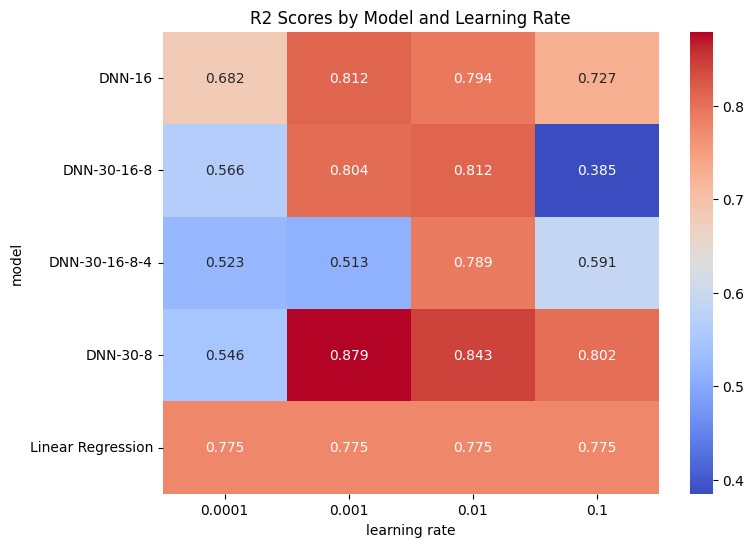

In [40]:
pivot = df.pivot(index="model", columns="learning rate", values="r2")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("R2 Scores by Model and Learning Rate")
plt.show()
